In [8]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [14]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=5000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()
protein_df

,mutant,protein_sequence,DMS_score,DMS_score_bin
10308,V544G,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.613682,0
6705,E354I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.864511,0
304,D18T,MKAKLLVLLYAFVATDATTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.774094,0
9142,F483V,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.423986,0
10592,L559I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.298089,0
...,...,...,...,...
9405,N497E,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,0.417371,1
4423,P234D,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.178611,0
1243,L67N,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.722072,0
8657,N457H,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.809659,0


(array([4296.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         704.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

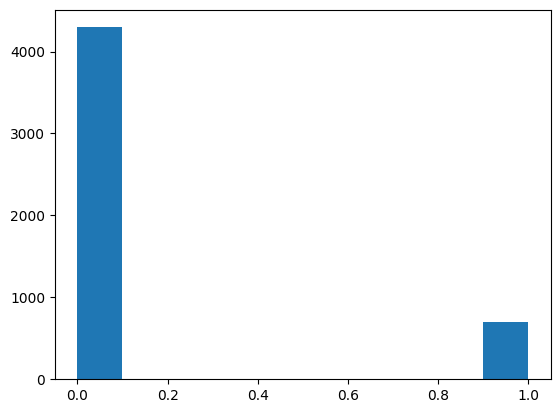

In [15]:
y_discretize_arr=np.digitize(y_arr,bins=[-0.5])
plt.hist(y_discretize_arr)

In [17]:
max_length=sequence_arr[0].__len__()
print("Max length of sequence:", max_length)
X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

Max length of sequence: 565
(5000, 11865)


In [18]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [19]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [20]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [21]:
#from proteinmlutils.ML_trainer import classifier_model_trainer
from proteinmlutils.data_stratifier import data_train_vs_test_splitting
sequence_arr=protein_df["protein_sequence"].tolist()
df=data_train_vs_test_splitting(X_arr, y_discretize_arr, sequence_arr, test_size=0.5)




Training+validation sample size: 2500
Test sample size: 2500


In [22]:
df.rename(columns={"sequence":"protein_sequence"}, inplace=True)
protein_df_combined=protein_df.join(df.set_index("protein_sequence"), on="protein_sequence", how="left")


In [23]:
#convert it to 2D numpy array
X_train = protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["X"]
X_train = np.array(X_train.tolist())
X_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["X"]
X_test = np.array(X_test.tolist())
y_train=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["y"].to_numpy()
y_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["y"].to_numpy()


In [24]:
from proteinmlutils import model_trainer
clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train)

rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="default")

y_pred = rf_classifier.predict(X_test)

Score on training: Recall= 0.9971671388101983 Precision= 1.0 F1 score= 0.9985815602836879


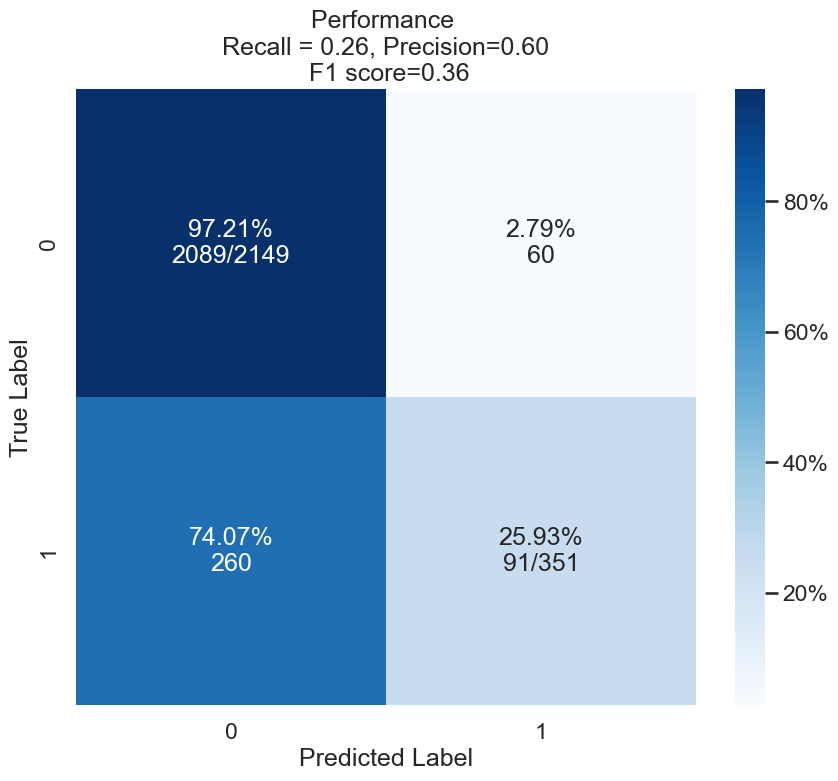

In [25]:
from proteinmlutils import model_eval
folder_name = "../output/DMS_Random_Forest_classifier_results"
model_eval.save_classification_report(y_test, y_pred, folder_name)
model_eval.save_confusion_matrix(y_test,y_pred, foldername=folder_name, labels=[0,1])

In [26]:
## Cross-validation
kwargs = {}
kwargs['scoring'] = ["f1", "precision", "recall", "accuracy"]
kwargs['n_iter'] = 5
kwargs['primary_scoring'] = 'f1'


clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train, **kwargs)
rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="CrossVal")

y_pred = rf_classifier.predict(X_test)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain fr

[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   1.4s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   1.5s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   1.6s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   2.7s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   2.9s


...

[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   9.9s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   8.8s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   9.0s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   8.3s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  30.7s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  31.0s
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  31.0s
Best parameters found:  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
Score on training: Recall= 1.0 Precision= 0.9697802197802198 F1 score= 0.9846582984658299
